# Subscription Survival and LTV

Product question: what CAC ceiling is reasonable after trial conversion and paid-user survival are accounted for?
Simulated subscription funnel with install, trial, paid conversion, tenure, and churn/censoring fields.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
sub_data = pd.read_csv('../data/subscriptions.csv')
sub_data.head(10)


,user_id,install_date,converted_to_trial,trial_converted,tenure_months,churned
0,U00000,2024-01-01,1,0,0,0
1,U00001,2024-01-01,0,0,0,0
2,U00002,2024-01-01,0,0,0,0
3,U00003,2024-01-01,0,0,0,0
4,U00004,2024-01-01,1,0,0,0
5,U00005,2024-01-01,1,1,2,1
6,U00006,2024-01-01,1,0,0,0
7,U00007,2024-01-01,0,0,0,0
8,U00008,2024-01-01,0,0,0,0
9,U00009,2024-01-01,0,0,0,0


### trial conversion funnel analysis

In [ ]:
installs = len(sub_data)
trials = sub_data['converted_to_trial'].sum()
paid = sub_data['trial_converted'].sum()

print(f"total installs:      {installs}")
print(f"trial signups:       {trials} ({trials/installs:.1%})")
print(f"paid conversions:    {paid} ({paid/trials:.1%}) of trials, ({paid/installs:.1%}) of installs")


total installs:      3000
trial signups:       1204 (40.1%)
paid conversions:    437 (36.3%) of trials, (14.6%) of installs


### cohort retention survival curves
calculate the retention curve for paid subscribers.

In [ ]:
paid_users = sub_data[sub_data['trial_converted'] == 1].copy()

retention_table = []
remaining = len(paid_users)
current_survival = 1.0
for m in range(1, 13):
    churned_this_month = len(paid_users[(paid_users['tenure_months'] == m) & (paid_users['churned'] == 1)])
    censored_this_month = len(paid_users[(paid_users['tenure_months'] == m) & (paid_users['churned'] == 0)])
    
    if remaining > 0:
        interval_survival = 1.0 - (churned_this_month / remaining)
    else:
        interval_survival = 1.0
    current_survival *= interval_survival
    
    retention_table.append({
        'month': m,
        'at_risk': remaining,
        'churned': churned_this_month,
        'censored': censored_this_month,
        'survival_pct': current_survival
    })
    remaining -= (churned_this_month + censored_this_month)

df_life = pd.DataFrame(retention_table)
df_life


,month,at_risk,churned,censored,survival_pct
0,1,437,20,4,0.954233
1,2,413,58,13,0.820225
2,3,342,47,5,0.707504
3,4,290,53,8,0.578201
4,5,229,49,9,0.454481
5,6,171,34,8,0.364117
6,7,129,22,3,0.302019
7,8,104,21,3,0.241035
8,9,80,18,2,0.186802
9,10,60,13,1,0.146328


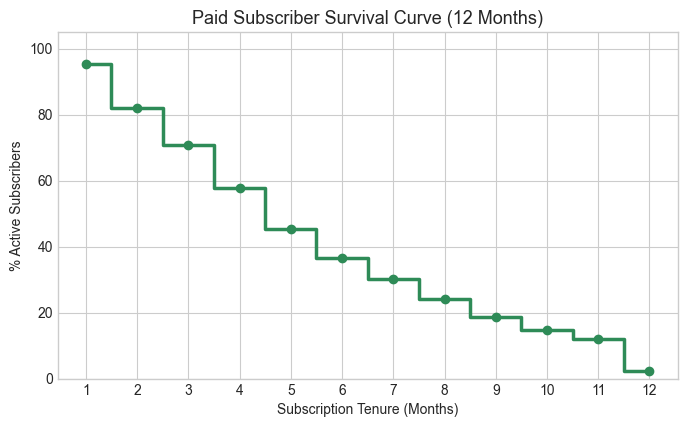

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.step(df_life['month'], df_life['survival_pct'] * 100, where='mid', color='#2e8b57', linewidth=2.5, marker='o')
plt.title('Paid Subscriber Survival Curve (12 Months)', fontsize=13)
plt.xlabel('Subscription Tenure (Months)')
plt.ylabel('% Active Subscribers')
plt.ylim(0, 105)
plt.xticks(range(1, 13))
plt.show()


### projecting lifetime value (LTV)
assuming subscription price is $14.99/mo with a gross margin of 80%.

In [ ]:
price = 14.99
margin = 0.80
arpu_mo = price * margin

ltv_12mo = arpu_mo * df_life['survival_pct'].sum()
print(f"Monthly ARPU (net): ${arpu_mo:.2f}")
print(f"12-Month LTV projection: ${ltv_12mo:.2f}")
print(f"Target CAC upper limit: ${ltv_12mo / 3:.2f}")


Monthly ARPU (net): $11.99
12-Month LTV projection: $58.76
Target CAC upper limit: $19.59
